In [1]:
from utils import (flag_rfi_channels, flag_outlier_dumps, vlsr_correction,
                    compute_cell_metrics, neighbor_qa, flag_outlier_pairs,
                    group_dumps_by_cell, compute_cell_gains,
                    apply_tsys_calibration, compute_R_for_dumps)
from plotters import plot_spectra_grid, plot_survey_mollweide
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
from collections import defaultdict
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt
import json
import numpy as np
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
HI_REST_MHZ = 1420.405751768
C_KMS = 299792.458

F1_MHZ = 1419.86
F2_MHZ = 1421.14

T_CAL_00 = 58.0  # K, pol 0
T_CAL_11 = 79.0  # K, pol 1

HPBW_DEG = 3.4

# --- RFI channel flagger (utils.flag_rfi_channels) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter (utils.flag_outlier_dumps) ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching (Section 4) ---
EDGE_TRIM_MHZ = 0.256

# --- Calibration (utils.compute_cell_gains / apply_tsys_calibration) ---
CAL_SPECTRUM_KEY = 'corr11'
CAL_GAIN_KEY = 'gain_11'

# --- Cross-session pair filter (utils.flag_outlier_pairs) ---
# Filter on T_B (K) so a session with anomalous T_sys becomes a population
# outlier in absolute units, not just spectral shape.
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'T_B_lsr'

# --- Per-cell metrics (utils.compute_cell_metrics) ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (utils.neighbor_qa) ---
# Operates on T_B (K), so W is in K*km/s. W_SCALE_FLOOR is the denominator
# floor for W_frac_resid: ~5 (R*km/s) * ~200 K T_sys ~ 1000 K*km/s.
# Brick-interleave grid (even b in {-4,-2,0,2,4}, odd b in {-3,-1,1,3} with
# l offset by Delta_l/2): 2.1 deg captures the 8 ring-1 neighbors -- 4 half-
# row diagonals at sep ~sqrt(2), and 4 same-axis neighbors at sep = 2.0.
NEIGHBOR_MAX_SEP_DEG = 2.1
MIN_NEIGHBORS = 2
W_Z_THRESH = 3.0
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 1000.0
PEAK_V_Z_THRESH = 3.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
REOBSERVE_PATH = Path('artifacts/main_reobserve.json')
MOLL_CENTER_L = 120.0

%matplotlib inline

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps

In [2]:
records = []
for data_dir in DATA_DIRS:
    survey = data_dir.name  # 'main' or 'nps'
    for session_dir in sorted(data_dir.glob('session_*')):
        for cell_dir in sorted(session_dir.glob('obs_*')) + sorted(session_dir.glob('cal_*')):
            for p in sorted(cell_dir.glob('*.npz')):
                with np.load(p, allow_pickle=True) as f:
                    records.append({
                        'path': p,
                        'survey': survey,
                        'session': f'{survey}/{session_dir.name}',
                        'target': str(f['target_name']),
                        'corr00': f['corr00'].astype(float),
                        'corr11': f['corr11'].astype(float),
                        'lo_mhz': float(f['lo_freq_mhz']),
                        'noise_on': bool(f['noise_on']),
                        'time': float(f['time']),
                        'alt': float(f['alt_deg']),
                        'az': float(f['az_deg']),
                        'ra': float(f['ra_deg']),
                        'dec': float(f['dec_deg']),
                    })

N = len(records)

# Galactic coordinates from RA/Dec
for r in records:
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg, 2)
    r['gb'] = round(c.galactic.b.deg)

sessions = sorted(set(r['session'] for r in records))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

# Integration time per dump (seconds): NBLOCKS * NSAMPLES / fs
INT_TIME_S = 1025 * 32768 / SAMPLE_RATE_HZ  # ~10.5 s


def _utc(ts):
    return dt.datetime.fromtimestamp(ts, dt.UTC).strftime('%Y-%m-%d %H:%M')


session_data = []
for s in sessions:
    s_records = [r for r in records if r['session'] == s]
    n_dumps = len(s_records)
    if n_dumps == 0:
        continue
    n_cells = len(set((r['gl'], r['gb']) for r in s_records if not r['noise_on']))
    times = [r['time'] for r in s_records]
    t0, t1 = min(times), max(times)
    wall_s = t1 - t0
    duty_pct = (INT_TIME_S * n_dumps / wall_s) * 100 if wall_s > 0 else float('nan')
    session_data.append({
        'Session': s,
        'UTC Start': _utc(t0),
        'UTC End':   _utc(t1),
        'Wall (min)': round(wall_s / 60, 1),
        'Obs. Cells': n_cells,
        'Dumps': n_dumps,
        'Duty %': round(duty_pct, 1),
    })
display(pd.DataFrame(session_data))

print(f'Total: {N} dumps ({n_sci} science, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')

,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-09 20:36,2026-05-09 23:45,189.5,103,824,76.1
1,main/session_002,2026-05-09 23:58,2026-05-10 03:46,227.7,122,976,75.0
2,main/session_003,2026-05-10 08:46,2026-05-10 18:50,604.2,328,2624,76.0
3,main/session_004,2026-05-10 18:52,2026-05-11 00:23,331.5,179,1432,75.6
4,main/session_005,2026-05-11 00:26,2026-05-11 00:27,1.3,1,8,106.9
5,main/session_006,2026-05-11 00:31,2026-05-11 04:07,216.6,116,928,74.9
6,nps/session_001,2026-05-11 05:08,2026-05-11 07:58,169.6,88,704,72.6


Total: 7496 dumps (5622 science, 1874 cal), 7 sessions, LO: [1419.86, 1421.14]


## 1b. Sun + Moon proximity check

Verify every observed dump is at least `SUN_AVOID_DEG` / `MOON_AVOID_DEG` from the Sun and Moon at its time of capture (the planner enforces this prospectively, but a long-running session can drift if either body has crossed onto a cell since planning).


In [3]:
from astropy.coordinates import get_sun, get_body
from astropy.time import Time

SUN_AVOID_DEG = 30.0
MOON_AVOID_DEG = 10.0

ts = np.array([r['time'] for r in records])
ras = np.deg2rad([r['ra'] for r in records])
decs = np.deg2rad([r['dec'] for r in records])

# Sun moves ~0.04 deg/min, Moon ~0.5 deg/h.  A 10-min grid + linear interp
# of (cos ra, sin ra, dec) is well below either threshold (Sun=30 deg, Moon=10 deg).
GRID_SEC = 600.0
t_lo, t_hi = ts.min() - 1, ts.max() + 1
t_grid = np.arange(t_lo, t_hi + GRID_SEC, GRID_SEC)
atime = Time(t_grid, format='unix')

def _interp_radec(body):
    ra = np.deg2rad(body.ra.deg)
    dec = np.deg2rad(body.dec.deg)
    ra_x = np.interp(ts, t_grid, np.cos(ra))
    ra_y = np.interp(ts, t_grid, np.sin(ra))
    return np.arctan2(ra_y, ra_x), np.interp(ts, t_grid, dec)

sun_ra_t,  sun_dec_t  = _interp_radec(get_sun(atime))
moon_ra_t, moon_dec_t = _interp_radec(get_body('moon', atime))

def _sep_deg(ra_b, dec_b):
    cos_sep = (np.sin(decs) * np.sin(dec_b)
               + np.cos(decs) * np.cos(dec_b) * np.cos(ras - ra_b))
    return np.rad2deg(np.arccos(np.clip(cos_sep, -1.0, 1.0)))

sun_sep  = _sep_deg(sun_ra_t,  sun_dec_t)
moon_sep = _sep_deg(moon_ra_t, moon_dec_t)

for body, sep, thr in [('Sun', sun_sep, SUN_AVOID_DEG),
                       ('Moon', moon_sep, MOON_AVOID_DEG)]:
    bad = sep < thr
    n_bad = int(bad.sum())
    print(f'{body:4s} proximity: {len(records)} dumps, threshold {thr:.0f} deg, '
          f'min={sep.min():.1f} deg, median={np.median(sep):.1f} deg')
    if n_bad:
        print(f'  WARNING: {n_bad} dumps within {thr:.0f} deg of the {body}')
        for i in np.argsort(sep)[:min(10, n_bad)]:
            r = records[i]
            print(f"    sep={sep[i]:5.2f} deg  l={r['gl']:6.2f} b={r['gb']:+3d}  "
                  f"{r['session']}/{Path(r['path']).name}")
    else:
        print(f'  All clear.')


Sun  proximity: 7496 dumps, threshold 30 deg, min=30.0 deg, median=66.8 deg
  All clear.
Moon proximity: 7496 dumps, threshold 10 deg, min=41.5 deg, median=100.1 deg
  All clear.


## 2. fftshift + RFI flagging + outlier dump filter

In [4]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0 / SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])
    r['stokes_I'] = r['corr11']  # pol 1 only -- pol 0 has bad noise-diode coupling at 3.2 MHz

n_flagged = sum(
    flag_rfi_channels(
        r['stokes_I'],
        window=RFI_WINDOW,
        sigma_thresh=RFI_SIGMA,
        degree=RFI_CHEB_DEGREE,
        sample_frac=RFI_SAMPLE_FRAC,
        extrema_order=RFI_EXTREMA_ORDER,
    )
    for r in records
)

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz, '
      f'dnu = {df_khz:.2f} kHz')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')
print('NOTE: using pol 1 (corr11) only')

Baseband: [-1.600, 1.597] MHz, dnu = 3.12 kHz
RFI flagged: 31872 samples across 7496 dumps
NOTE: using pol 1 (corr11) only


In [5]:
outlier_records = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
N = len(records)

print(f'Outlier dump filter (spectral shape): removed {len(outlier_records)} dumps')
print(f'  (flag if >{SHAPE_FRAC_THRESH:.0%} of channels deviate '
      f'>{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {N} dumps')

Outlier dump filter (spectral shape): removed 0 dumps
  (flag if >5% of channels deviate >5% from group median)
Remaining: 7496 dumps


## 4. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.

In [6]:
lo1, lo2 = F1_MHZ, F2_MHZ
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)
dv_kms = np.abs(np.median(np.diff(v_overlap)))

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')

# Frequency-switched R per (session, cell)
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

cell_results = {}
for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]
    for dr in sessions:
        dr_dumps = [r for r in sci_dumps if r['session'] == dr]
        result = compute_R_for_dumps(dr_dumps, lo1, lo2, overlap_mask, v_overlap)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


/home/ikaros/projects/ay-121/labs/04/utils/freqswitch.py:107: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R_cat, axis=0)


## 5. Per-cell gain calibration

Each cell has its own cal-on/cal-off pair. Compute gain per cell,
then T_sys = P_off / gain. Convert R -> T_B = R * T_sys.

In [7]:
dc_mask = np.ones(NFFT, dtype=bool)
dc_mask[DC_BIN] = False

# Per-cell channel-dependent gain g(nu) and T_sys(nu) from pol 1 only
# (pol 0 has unreliable noise-diode coupling at 3.2 MHz). The smoothed gain
# spectrum is inverted to T_sys(nu); the scalar 'T_sys' summary is the band
# median over the overlap region.
cal_dumps, obs_dumps_by_cell = group_dumps_by_cell(records)
cell_gains = compute_cell_gains(
    cal_dumps, obs_dumps_by_cell, dc_mask, T_CAL_11,
    spectrum_key=CAL_SPECTRUM_KEY, gain_key=CAL_GAIN_KEY,
)
print(f'Gain computed for {len(cell_gains)} (session, cell) entries')

cell_results_TB = apply_tsys_calibration(
    cell_results, cell_gains, obs_dumps_by_cell, dc_mask,
    spectrum_key=CAL_SPECTRUM_KEY, gain_key=CAL_GAIN_KEY,
    overlap_mask=overlap_mask,
)
print(f'Calibrated {len(cell_results_TB)} (session, cell) entries')

CAL_GAIN_SCALAR_KEY = CAL_GAIN_KEY + '_scalar'

# Gain summary (band-median scalars; full T_sys(nu) lives on each entry).
gain_rows = []
for (dr, gl, gb), v in sorted(cell_results_TB.items()):
    gain_rows.append({
        'session': dr, 'gl': gl, 'gb': gb,
        CAL_GAIN_KEY: v[CAL_GAIN_SCALAR_KEY],
        'T_sys': v['T_sys'],
    })
gain_df = pd.DataFrame(gain_rows)
if len(gain_df):
    print(f'\nGain stats (pol 1 only, band-median scalars):')
    print(f'  {CAL_GAIN_KEY}: {gain_df[CAL_GAIN_KEY].median():.2f} (median), '
          f'range [{gain_df[CAL_GAIN_KEY].min():.2f}, {gain_df[CAL_GAIN_KEY].max():.2f}]')
    print(f'  T_sys:   {gain_df["T_sys"].median():.0f} K (median), '
          f'range [{gain_df["T_sys"].min():.0f}, {gain_df["T_sys"].max():.0f}] K')

    # Spectral T_sys diagnostics: how flat is T_sys(nu) within each cell?
    tsys_overlap_arrs = [v['T_sys_overlap']
                         for v in cell_results_TB.values()
                         if np.isfinite(v['T_sys'])]
    if tsys_overlap_arrs:
        rel_spread = np.array([
            float(np.nanstd(a) / np.nanmedian(a))
            for a in tsys_overlap_arrs
            if np.isfinite(np.nanmedian(a)) and np.nanmedian(a) > 0
        ])
        if rel_spread.size:
            print(f'  T_sys(nu) relative spread within overlap: '
                  f'median {np.median(rel_spread)*100:.1f}%, '
                  f'p95 {np.percentile(rel_spread, 95)*100:.1f}%')

/home/ikaros/projects/ay-121/labs/04/utils/calibration.py:165: RuntimeWarning: Mean of empty slice
  P_on = np.nanmean([c[spectrum_key] for c in cals], axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/calibration.py:166: RuntimeWarning: Mean of empty slice
  P_off = np.nanmean([o[spectrum_key] for o in obs], axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/calibration.py:219: RuntimeWarning: Mean of empty slice
  P_off_nu = np.nanmean([o[spectrum_key] for o in obs], axis=0)


Gain computed for 937 (session, cell) entries
Calibrated 937 (session, cell) entries

Gain stats (pol 1 only, band-median scalars):
  gain_11: 3.54 (median), range [0.95, 5.97]
  T_sys:   172 K (median), range [108, 578] K
  T_sys(nu) relative spread within overlap: median 10.0%, p95 13.0%


## 6. LSR correction, cross-session pair filter, and combine

Build per-pair R for each cell across all sessions, LSR-shift each pair onto a
common grid, reject outlier pairs via population MAD (cross-session), then
average the surviving pairs. Cells with fewer than `MIN_VIABLE_PAIRS` after
filtering are queued for reobservation.

In [8]:
print('Computing LSR corrections...')
cell_dr_groups = defaultdict(list)
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    cell_dr_groups[(r['session'], r['gl'], r['gb'])].append(r)

session_cell_vcorr = {}
for key, group in cell_dr_groups.items():
    r0 = group[0]
    mean_t = np.mean([r['time'] for r in group])
    session_cell_vcorr[key] = vlsr_correction(r0['ra'], r0['dec'], mean_t)

sci_vcorr = list(session_cell_vcorr.values())
mean_vcorr = np.mean(sci_vcorr) if sci_vcorr else 0.0
v_lsr_overlap = v_overlap + mean_vcorr
v_lsr_inc = v_lsr_overlap[::-1]

if sci_vcorr:
    print(f'v_corr range: {min(sci_vcorr):.2f} to {max(sci_vcorr):.2f} km/s '
          f'(mean {mean_vcorr:.2f})')
    print(f'Velocity (LSR): [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')
else:
    print('No science dumps -- skipping LSR correction')


def _interp_to_lsr(spec_topo, v_topo_inc, v_lsr_inc_):
    """Interp a topocentric overlap spectrum onto the common LSR grid."""
    return np.interp(v_lsr_inc_, v_topo_inc[::-1],
                     spec_topo[::-1],
                     left=np.nan, right=np.nan)[::-1]


# Build per-pair (R_lsr, T_sys_lsr, T_B_lsr) for each (gl, gb), all on the
# common LSR grid. T_sys is now channel-dependent: T_B_lsr(v) = R_lsr(v) *
# T_sys_lsr(v) per pair, so spectral structure of T_sys (bandpass curvature,
# diode response) propagates correctly through the cross-session average.
cell_pairs = defaultdict(list)
n_pairs_no_tsys = 0

for (dr, gl, gb), dumps in obs_dumps_by_cell.items():
    d1 = [r for r in dumps if r['lo_mhz'] == lo1]
    d2 = [r for r in dumps if r['lo_mhz'] == lo2]
    n_p = min(len(d1), len(d2))
    if n_p == 0:
        continue

    tb_key = (dr, gl, gb)
    tb_entry = cell_results_TB.get(tb_key)
    if tb_entry is None or not np.isfinite(tb_entry['T_sys']):
        n_pairs_no_tsys += n_p
        continue

    T_sys_overlap = tb_entry['T_sys_overlap']  # topocentric, overlap region

    I1 = np.array([r['stokes_I'] for r in d1[:n_p]])
    I2 = np.array([r['stokes_I'] for r in d2[:n_p]])
    R_pairs = (I1 - I2) / I2  # (n_p, NFFT)
    R_pairs_ov = R_pairs[:, overlap_mask]

    v_corr = session_cell_vcorr.get((dr, gl, gb), 0.0)
    v_shifted = v_overlap + v_corr

    T_sys_lsr = _interp_to_lsr(T_sys_overlap, v_shifted, v_lsr_inc)

    for i in range(n_p):
        R_lsr = _interp_to_lsr(R_pairs_ov[i], v_shifted, v_lsr_inc)
        cell_pairs[(gl, gb)].append({
            'session': dr,
            'pair_idx': i,
            'R_lsr': R_lsr,
            'T_sys_lsr': T_sys_lsr,
            'T_B_lsr': R_lsr * T_sys_lsr,
        })

if n_pairs_no_tsys:
    print(f'Skipped {n_pairs_no_tsys} pairs with missing T_sys')

# Cross-session per-pair outlier filter on T_B (K).
n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter (on {PAIR_SPECTRUM_KEY}): flagged '
      f'{len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

# Aggregate viable pairs into cell_combined. T_B carries each pair's
# channel-dependent T_sys; T_sys_nu is the average T_sys spectrum on the
# LSR grid; T_sys (scalar) is the band-median for QA / legacy reporting.
cell_combined = {}
cells_insufficient_pairs = []

for (gl, gb), pairs in viable_pairs_per_cell.items():
    TB_list = [p['T_B_lsr'] for p in pairs]
    R_list = [p['R_lsr'] for p in pairs]
    Tsys_lsr_list = [p['T_sys_lsr'] for p in pairs]

    n_viable = len(TB_list)
    if n_viable == 0:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': 0})
        continue

    T_sys_nu = np.nanmean(Tsys_lsr_list, axis=0)
    cell_combined[(gl, gb)] = {
        'T_B': np.nanmean(TB_list, axis=0),
        'R': np.nanmean(R_list, axis=0),
        'T_sys_nu': T_sys_nu,
        'T_sys': float(np.nanmedian(T_sys_nu)),
        'n_pairs': n_viable,
    }

    if n_viable < MIN_VIABLE_PAIRS:
        cells_insufficient_pairs.append({'l': gl, 'b': int(gb), 'n_viable': n_viable})

n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['T_B'])) >= 8)
print(f'Combined (LSR): {len(cell_combined)} cells ({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')

# Sanity check: scalar-T_sys vs spectral-T_sys integrated W on (l=120, b=0)
# (the canonical lab-manual reference cell). Difference should be small (few %)
# if the spectral correction is well-behaved.
ref_key = (120.0, 0)
ref_alt_keys = [k for k in cell_combined if abs(k[0] - 120.0) < 0.5 and k[1] == 0]
if ref_alt_keys:
    rk = ref_alt_keys[0]
    cv = cell_combined[rk]
    W_spectral = float(np.nansum(cv['T_B']) * dv_kms)
    W_scalar = float(np.nansum(cv['R'] * cv['T_sys']) * dv_kms)
    if W_scalar != 0:
        delta = (W_spectral - W_scalar) / W_scalar
        print(f'Sanity (l={rk[0]:.2f}, b={rk[1]}): '
              f'W_spectral={W_spectral:.0f}, W_scalar={W_scalar:.0f} K*km/s, '
              f'delta={delta*100:+.2f}%')
else:
    print('Sanity-check cell (l~120, b=0) not present in cell_combined -- skipping.')

Computing LSR corrections...
v_corr range: -41.20 to 41.03 km/s (mean -3.24)
Velocity (LSR): [-171, 125] km/s


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:555: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:556: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter (on T_B_lsr): flagged 3/2811 pairs (NSIGMA=5.0, frac>15%)
Combined (LSR): 821 cells (821 with >=8 valid channels)
Cells with <3 viable pairs: 3
Sanity (l=120.00, b=0): W_spectral=7046, W_scalar=6779 K*km/s, delta=+3.95%


/tmp/ipykernel_42478/1142215317.py:108: RuntimeWarning: Mean of empty slice
  T_sys_nu = np.nanmean(Tsys_lsr_list, axis=0)
/tmp/ipykernel_42478/1142215317.py:110: RuntimeWarning: Mean of empty slice
  'T_B': np.nanmean(TB_list, axis=0),
/tmp/ipykernel_42478/1142215317.py:111: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(R_list, axis=0),


# N. Neighbour-based QA

In [9]:
# Neighbor QA disabled.  Re-enable by uncommenting below and deleting `neighbor_cells = []`.
neighbor_cells = []
# # QA runs on T_B (K), so W is in K*km/s and noise_rms is in K. This makes the
# # neighbor comparison and W_sigma_floor physically meaningful and not biased
# # by cell-to-cell T_sys variation.
# cell_combined_qa = {
#     k: {'R_overlap': v['T_B'], 'n_pairs': v['n_pairs']}
#     for k, v in cell_combined.items()
# }
#
# cell_metrics = compute_cell_metrics(
#     cell_combined_qa, v_lsr_overlap, dv_kms,
#     min_valid_ch=METRIC_MIN_VALID_CH,
#     noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
#     signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
#     signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
#     smooth_kernel=METRIC_SMOOTH_KERNEL,
#     peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
#     peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
#     min_noise_ch=METRIC_MIN_NOISE_CH,
# )
# neighbor_cells = neighbor_qa(
#     cell_metrics,
#     dv_kms=dv_kms,
#     hpbw_deg=HPBW_DEG,
#     neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
#     min_neighbors=MIN_NEIGHBORS,
#     w_z_thresh=W_Z_THRESH,
#     w_frac_thresh=W_FRAC_THRESH,
#     w_scale_floor=W_SCALE_FLOOR,
#     peak_v_z_thresh=PEAK_V_Z_THRESH,
#     peak_v_abs_thresh=PEAK_V_ABS_THRESH,
#     peak_v_min_sigma=PEAK_V_MIN_SIGMA,
#     peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
#     bimodal_min_ratio=BIMODAL_MIN_RATIO,
# )
#
# neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
# neighbor_w_flag_count = sum(1 for c in neighbor_cells if c['W_flag'])
# neighbor_peak_flag_count = sum(1 for c in neighbor_cells if c['peak_v_flag'])
#
# print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed (on T_B)')
# print(f'  Flags: W={neighbor_w_flag_count}, peak_v={neighbor_peak_flag_count}, '
#       f'any={len(neighbor_flagged)}')
#
# if neighbor_flagged:
#     print('  Most deviant cells:')
#
#     def severity(cell):
#         w_score = abs(cell['W_frac_resid']) if np.isfinite(cell['W_frac_resid']) else 0.0
#         v_score = abs(cell['peak_v_z']) if np.isfinite(cell['peak_v_z']) else 0.0
#         return max(w_score, v_score)
#
#     for cell in sorted(neighbor_flagged, key=severity, reverse=True)[:12]:
#         print(
#             f"    l={cell['gl']:6.2f} b={cell['gb']:3d} "
#             f"W={cell['W']:+.1f} K*km/s (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
#             f"v_peak={cell['peak_v']:+.1f} km/s "
#             f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
#             f"n={cell['neighbor_count']}"
#         )


# N+. T_sys QA

Per-cell `T_sys` is the mean across viable pairs in `cell_combined`. Flag
cells whose `T_sys` lies more than `T_SYS_NSIGMA` robust standard
deviations (1.4826 * MAD) from the population median. Severe T_sys
excursions usually point to a bad cal-on/off block (noise diode partially
fired, scan boundary inside the cal pair, or unusually high ambient
temperature), and propagate silently into `T_B` since `T_B = R * T_sys`.

In [10]:
# T_sys QA disabled.  Re-enable by uncommenting below and deleting `tsys_flagged = []`.
tsys_flagged = []
# T_SYS_NSIGMA = 4.0
# T_SYS_ABS_LO = 80.0    # K, hard floor: any cell below this is suspect
# T_SYS_ABS_HI = 300.0   # K, hard ceiling
#
# # Build per-cell T_sys array from cell_combined
# tsys_cells = []
# for (gl, gb), v in cell_combined.items():
#     tsys = float(v.get('T_sys', np.nan))
#     if not np.isfinite(tsys):
#         continue
#     tsys_cells.append({'gl': gl, 'gb': gb, 'T_sys': tsys,
#                        'n_pairs': v.get('n_pairs', 0)})
#
# tsys_arr = np.array([c['T_sys'] for c in tsys_cells])
# tsys_med = float(np.median(tsys_arr))
# tsys_mad = float(np.median(np.abs(tsys_arr - tsys_med)))
# tsys_sigma = 1.4826 * tsys_mad if tsys_mad > 0 else np.nan
#
# for c in tsys_cells:
#     z = (c['T_sys'] - tsys_med) / tsys_sigma if np.isfinite(tsys_sigma) else 0.0
#     c['T_sys_z'] = z
#     c['T_sys_flag'] = (abs(z) > T_SYS_NSIGMA
#                       or c['T_sys'] < T_SYS_ABS_LO
#                       or c['T_sys'] > T_SYS_ABS_HI)
#
# tsys_flagged = [c for c in tsys_cells if c['T_sys_flag']]
#
# print(f'T_sys QA: {len(tsys_cells)} cells analyzed')
# print(f'  median = {tsys_med:.1f} K, robust sigma = {tsys_sigma:.1f} K')
# print(f'  threshold: |z| > {T_SYS_NSIGMA} OR T_sys outside '
#       f'[{T_SYS_ABS_LO:.0f}, {T_SYS_ABS_HI:.0f}] K')
# print(f'  Flagged: {len(tsys_flagged)} cells')
#
# if tsys_flagged:
#     print('  Most deviant cells:')
#     for c in sorted(tsys_flagged, key=lambda x: abs(x['T_sys_z']),
#                     reverse=True)[:12]:
#         print(f"    l={c['gl']:6.2f} b={c['gb']:+3d} "
#               f"T_sys={c['T_sys']:6.1f} K  z={c['T_sys_z']:+.2f}  "
#               f"n_pairs={c['n_pairs']}")
#


In [11]:
# Cells to reobserve: union of neighbor-QA flags, insufficient pairs, T_sys outliers.
reobs_map = {}  # (l, b) -> {'l', 'b', 'reason'}

for c in neighbor_cells:
    if not (c['W_flag'] or c['peak_v_flag']):
        continue
    flags = []
    if c['W_flag']:
        flags.append('W')
    if c['peak_v_flag']:
        flags.append('peak_v')
    key = (c['gl'], int(c['gb']))
    reobs_map[key] = {'l': c['gl'], 'b': int(c['gb']),
                      'reason': '+'.join(flags)}

for c in cells_insufficient_pairs:
    key = (c['l'], int(c['b']))
    tag = f"insufficient_pairs(n={c['n_viable']})"
    if key in reobs_map:
        reobs_map[key]['reason'] += '+' + tag
    else:
        reobs_map[key] = {'l': c['l'], 'b': int(c['b']), 'reason': tag}

for c in tsys_flagged:
    key = (c['gl'], int(c['gb']))
    tag = f"T_sys({c['T_sys']:.0f}K,z={c['T_sys_z']:+.1f})"
    if key in reobs_map:
        reobs_map[key]['reason'] += '+' + tag
    else:
        reobs_map[key] = {'l': c['gl'], 'b': int(c['gb']), 'reason': tag}

reobs = sorted(reobs_map.values(), key=lambda r: (r['b'], r['l']))

REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:7.2f} b={r['b']:+3d}  ({r['reason']})")


Wrote artifacts/main_reobserve.json -- 3 cells
  l= 150.00 b= +0  (insufficient_pairs(n=2))
  l= 234.63 b= +6  (insufficient_pairs(n=2))
  l=  19.87 b=+62  (insufficient_pairs(n=2))


In [12]:
# Cells the rest of the pipeline does not trust.
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
# (T_sys exclusion disabled) qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

# Build per-(session, cell) R from the cross-session-filtered viable pairs.
# (Spectra are on the common LSR grid, not topocentric.)
viable_per_session_cell = defaultdict(list)
for (gl, gb), pairs in viable_pairs_per_cell.items():
    if (gl, gb) in excluded_cells:
        continue
    for p in pairs:
        viable_per_session_cell[(p['session'], gl, gb)].append(p['R_lsr'])


def _safe_nanmean_stack(rs):
    """nanmean over axis 0 without a warning when some columns are all-NaN."""
    stack = np.array(rs)
    col_has_data = np.any(np.isfinite(stack), axis=0)
    mean = np.full(stack.shape[1], np.nan)
    if col_has_data.any():
        mean[col_has_data] = np.nanmean(stack[:, col_has_data], axis=0)
    return mean


with PdfPages('artifacts/spectra_per_session.pdf') as pdf:
    for dr in sessions:
        dr_spectra = {
            (l, b): _safe_nanmean_stack(rs)
            for (d, l, b), rs in viable_per_session_cell.items()
            if d == dr
        }
        if not dr_spectra:
            continue
        result = plot_spectra_grid(
            v_lsr_overlap, dr_spectra,
            ncols=5,
            color='C0',
            title=f'{dr} -- {len(dr_spectra)} pointings '
                  f'(post pair filter + QA, LSR frame)',
        )
        figs = result if isinstance(result, list) else [result]
        for f in figs:
            pdf.savefig(f)
            plt.close(f)

n_excluded = len(excluded_cells)
n_tsys = sum(1 for c in tsys_flagged)
print(f'Saved spectra_per_session.pdf '
      f'(excluded {n_excluded} cells: {len(qa_flagged_set)} QA '
      f'[incl. {n_tsys} T_sys] + {len(insufficient_set)} insufficient-pairs)')


Saved spectra_per_session.pdf (excluded 3 cells: 0 QA [incl. 0 T_sys] + 3 insufficient-pairs)


## 7a. Integrated frequency-switched ratio map W_R(l, b)

Same integration, but on the dimensionless frequency-switched ratio R(v)
rather than the calibrated brightness temperature T_B. Useful as a
sanity check decoupled from the per-cell T_sys calibration: structure
appearing here but not in W(l, b) (or vice versa) points to gain or
T_sys issues rather than astrophysics.

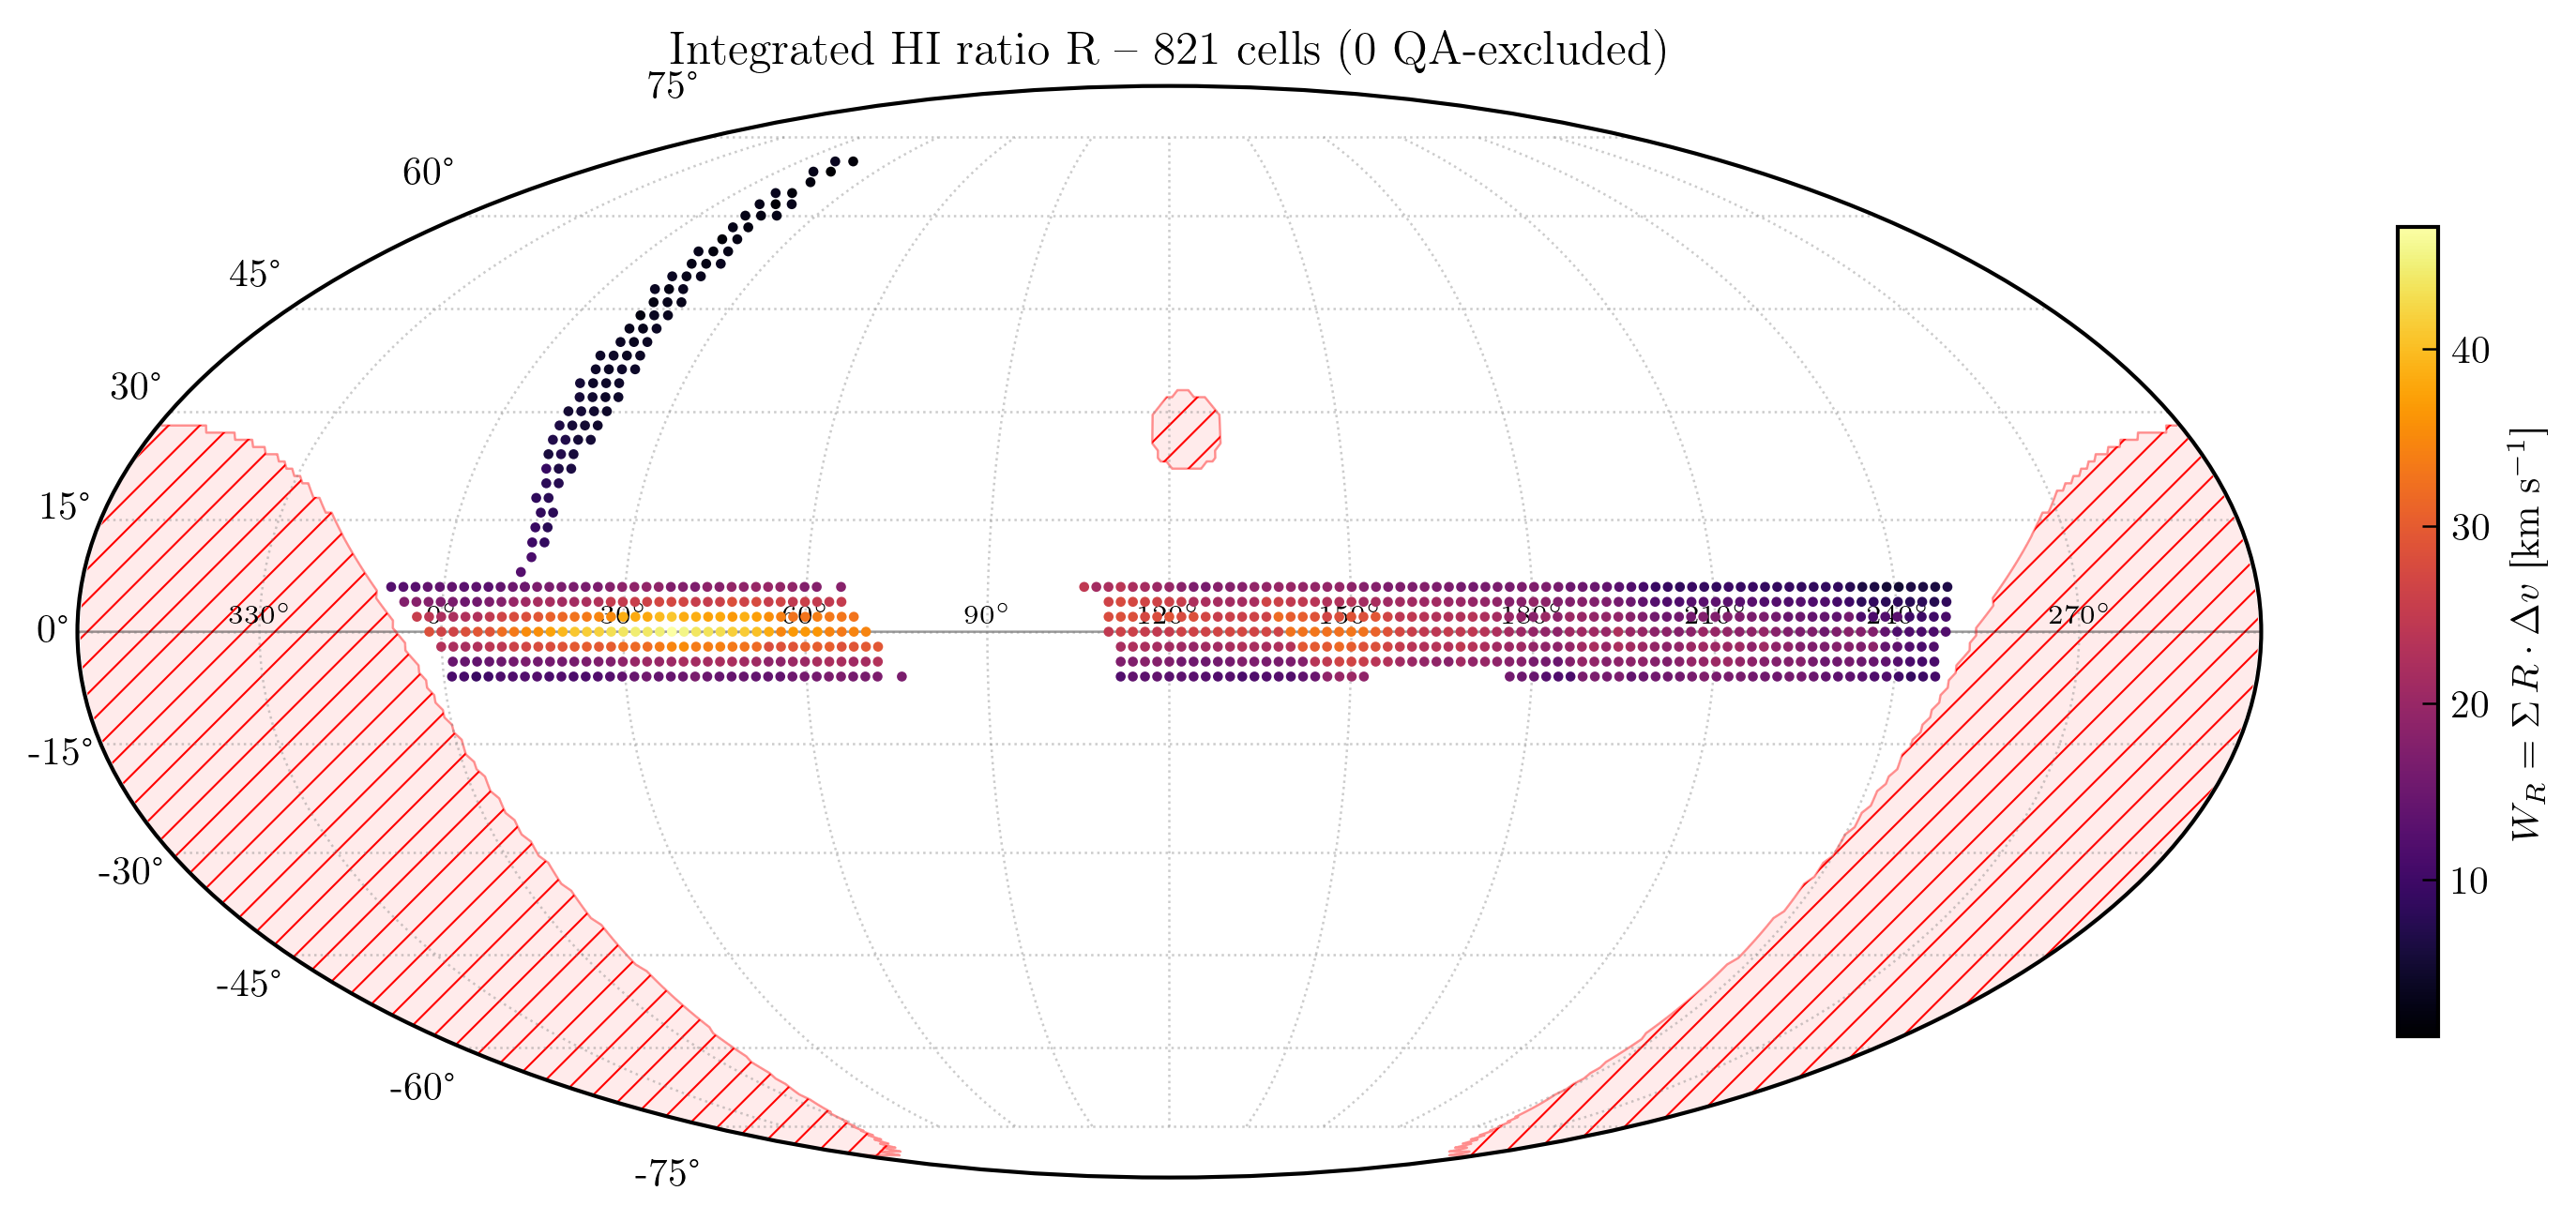

In [13]:
# QA-flagged cells to exclude (neighbor + T_sys outliers)
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
# (T_sys exclusion disabled) qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}

# Build arrays from cell_combined, excluding QA-flagged cells
cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]
gl_arr = np.array([k[0] for k in cell_keys_clean])
gb_arr = np.array([k[1] for k in cell_keys_clean])
R_stack = np.array([cell_combined[k]['R'] for k in cell_keys_clean])

# Integrated frequency-switched ratio: W_R = sum(R) * dv
W_R = np.nansum(R_stack, axis=1) * dv_kms

valid_R = np.isfinite(W_R)

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI ratio R -- {valid_R.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
)
plt.show()


## 7. Integrated intensity map W(l, b)

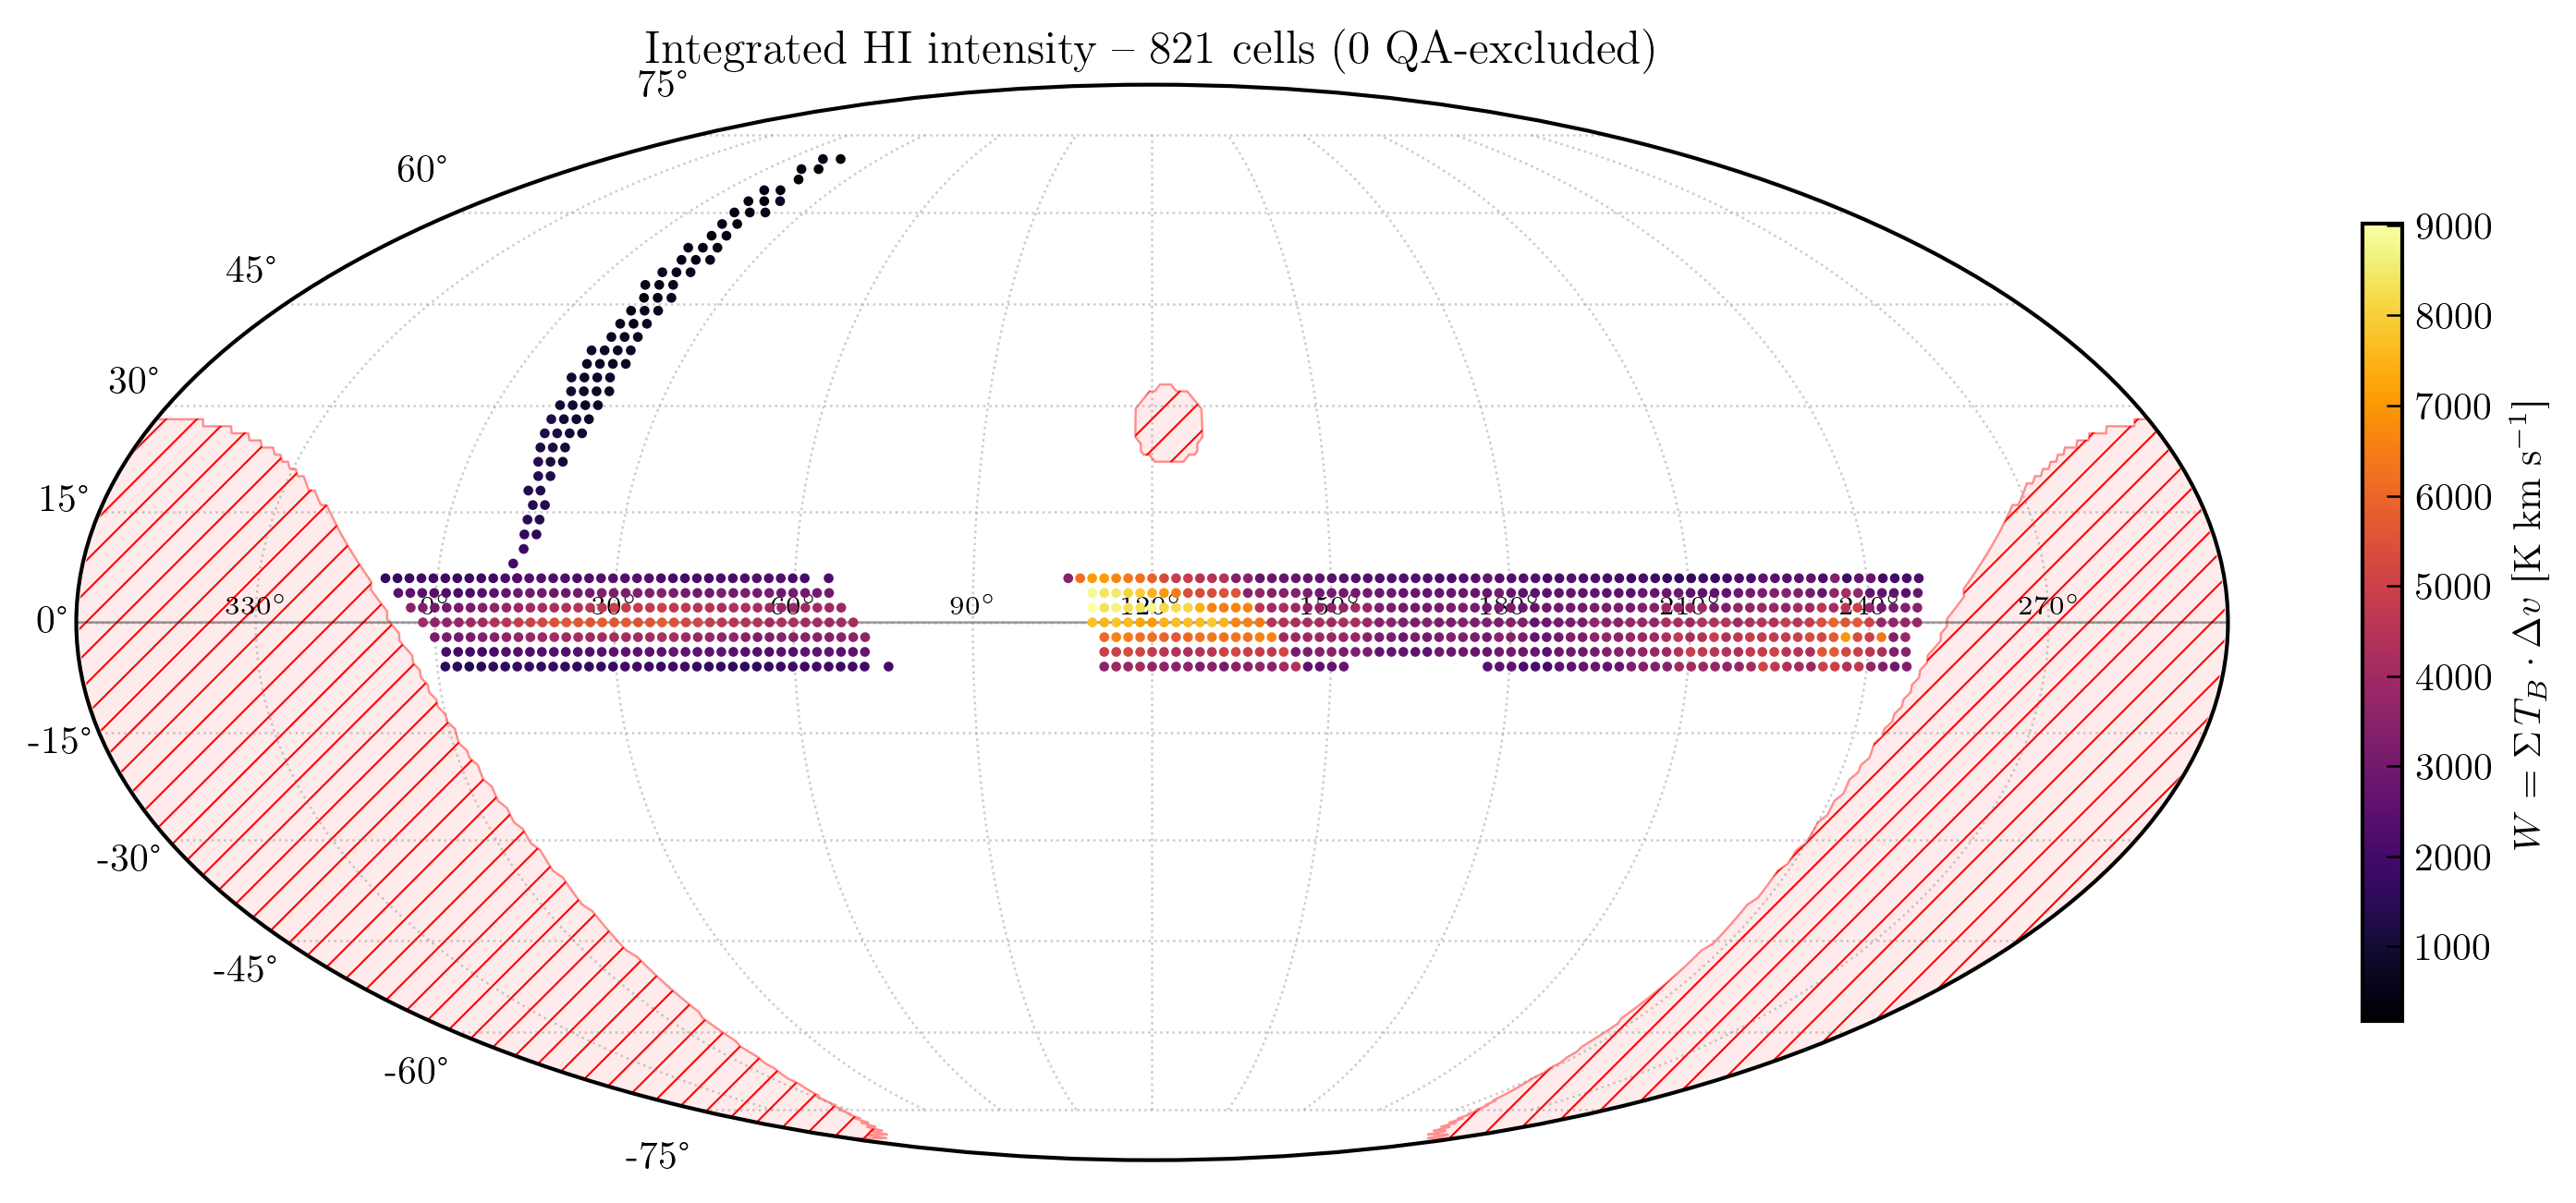

In [14]:
# QA-flagged cells to exclude (neighbor + T_sys outliers)
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
# (T_sys exclusion disabled) qa_flagged_set |= {(c['gl'], c['gb']) for c in tsys_flagged}

# Build arrays from cell_combined, excluding QA-flagged cells
cell_keys_clean = [k for k in cell_combined if k not in qa_flagged_set]
gl_arr = np.array([k[0] for k in cell_keys_clean])
gb_arr = np.array([k[1] for k in cell_keys_clean])
TB_stack = np.array([cell_combined[k]['T_B'] for k in cell_keys_clean])

# Integrated intensity: W = sum(T_B) * dv
W = np.nansum(TB_stack, axis=1) * dv_kms

valid = np.isfinite(W)

fig, ax = plot_survey_mollweide(
    gl_arr[valid], gb_arr[valid], W[valid],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W = \Sigma\, T_B \cdot \Delta v$ [K km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI intensity -- {valid.sum()} cells ({len(qa_flagged_set)} QA-excluded)',
)
plt.show()


In [15]:
# Export state for scan_load_lv.ipynb / scan_load_diagnostics.ipynb.
import pickle

STATE_PATH = Path('artifacts/scan_load_state.pkl')
tsys_by_session_cell = {
    key: float(v['T_sys'])
    for key, v in cell_results_TB.items()
    if np.isfinite(v.get('T_sys', np.nan))
}
tsys_nu_by_session_cell = {
    key: np.asarray(v['T_sys_nu'], dtype=float)
    for key, v in cell_results_TB.items()
    if np.isfinite(v.get('T_sys', np.nan))
}
tsys_overlap_by_session_cell = {
    key: np.asarray(v['T_sys_overlap'], dtype=float)
    for key, v in cell_results_TB.items()
    if np.isfinite(v.get('T_sys', np.nan))
}
gain_by_session_cell = {
    key: float(v[CAL_GAIN_KEY + '_scalar'])
    for key, v in cell_results_TB.items()
    if np.isfinite(v.get(CAL_GAIN_KEY + '_scalar', np.nan))
}
gain_nu_by_session_cell = {
    key: np.asarray(v[CAL_GAIN_KEY], dtype=float)
    for key, v in cell_results_TB.items()
    if v.get(CAL_GAIN_KEY) is not None
}
state = {
    'cell_combined': cell_combined,
    'qa_flagged_set': qa_flagged_set,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'tsys_by_session_cell': tsys_by_session_cell,
    'tsys_nu_by_session_cell': tsys_nu_by_session_cell,
    'tsys_overlap_by_session_cell': tsys_overlap_by_session_cell,
    'gain_by_session_cell': gain_by_session_cell,
    'gain_nu_by_session_cell': gain_nu_by_session_cell,
    'overlap_mask': overlap_mask,
    'sessions': sessions,
    'T_CAL_11': T_CAL_11,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} cells, {len(qa_flagged_set)} QA-flagged, '
      f'{len(tsys_by_session_cell)} (session,cell) T_sys entries '
      f'({len(tsys_nu_by_session_cell)} with T_sys(nu) spectra)')

Wrote artifacts/scan_load_state.pkl (27.87 MB) -- 821 cells, 0 QA-flagged, 937 (session,cell) T_sys entries (937 with T_sys(nu) spectra)
